# 01 — EDA & Preprocessing
**Dataset:** new-thyroid.csv | 215 mẫu | 5 features | 3 classes  
**Classes:** 1=Normal (150), 2=Hyper (35), 3=Hypo (30)

In [1]:
import sys; sys.path.append('../src')
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from preprocess import load_raw, check_data_quality, preprocess, CLASS_NAMES

EDA_DIR = Path('../results/figures/eda_plots')
EDA_DIR.mkdir(parents=True, exist_ok=True)
Path('../data/processed').mkdir(parents=True, exist_ok=True)

df = load_raw('../data/raw/new-thyroid.csv')
check_data_quality(df)


Shape       : (215, 6)
Dtypes      :
T3_resin              int64
Thyroxin            float64
Triiodothyronine    float64
TSH_basal           float64
TSH_diff            float64
class                 int64
dtype: object

Missing values:
T3_resin            0
Thyroxin            0
Triiodothyronine    0
TSH_basal           0
TSH_diff            0
class               0
dtype: int64

Duplicate rows: 0

Class distribution:
class
1    150
2     35
3     30
Name: count, dtype: int64

Describe:
       T3_resin  Thyroxin  Triiodothyronine  TSH_basal  TSH_diff   class
count    215.00     215.0            215.00     215.00    215.00  215.00
mean     109.60       9.8              2.05       2.88      4.20    1.44
std       13.15       4.7              1.42       6.12      8.07    0.73
min       65.00       0.5              0.20       0.10     -0.70    1.00
25%      103.00       7.1              1.35       1.00      0.55    1.00
50%      110.00       9.2              1.70       1.30      2.00    1.0

## 1. Class distribution

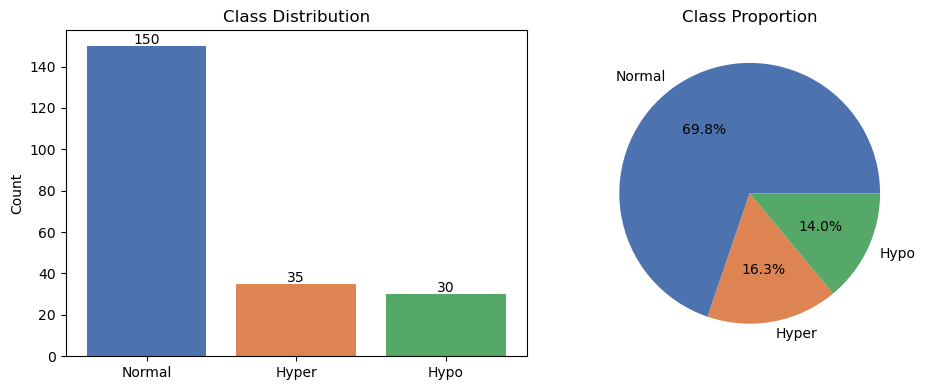

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
counts = df['class'].value_counts().sort_index()
axes[0].bar([CLASS_NAMES[i] for i in counts.index], counts.values,
            color=['#4C72B0','#DD8452','#55A868'])
axes[0].set_title('Class Distribution'); axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+1, str(v), ha='center', fontsize=10)

# Pie chart
axes[1].pie(counts.values, labels=[CLASS_NAMES[i] for i in counts.index],
            autopct='%1.1f%%', colors=['#4C72B0','#DD8452','#55A868'])
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig(str(EDA_DIR / 'class_distribution.png'), dpi=150)
plt.show()


## 2. Feature distributions by class

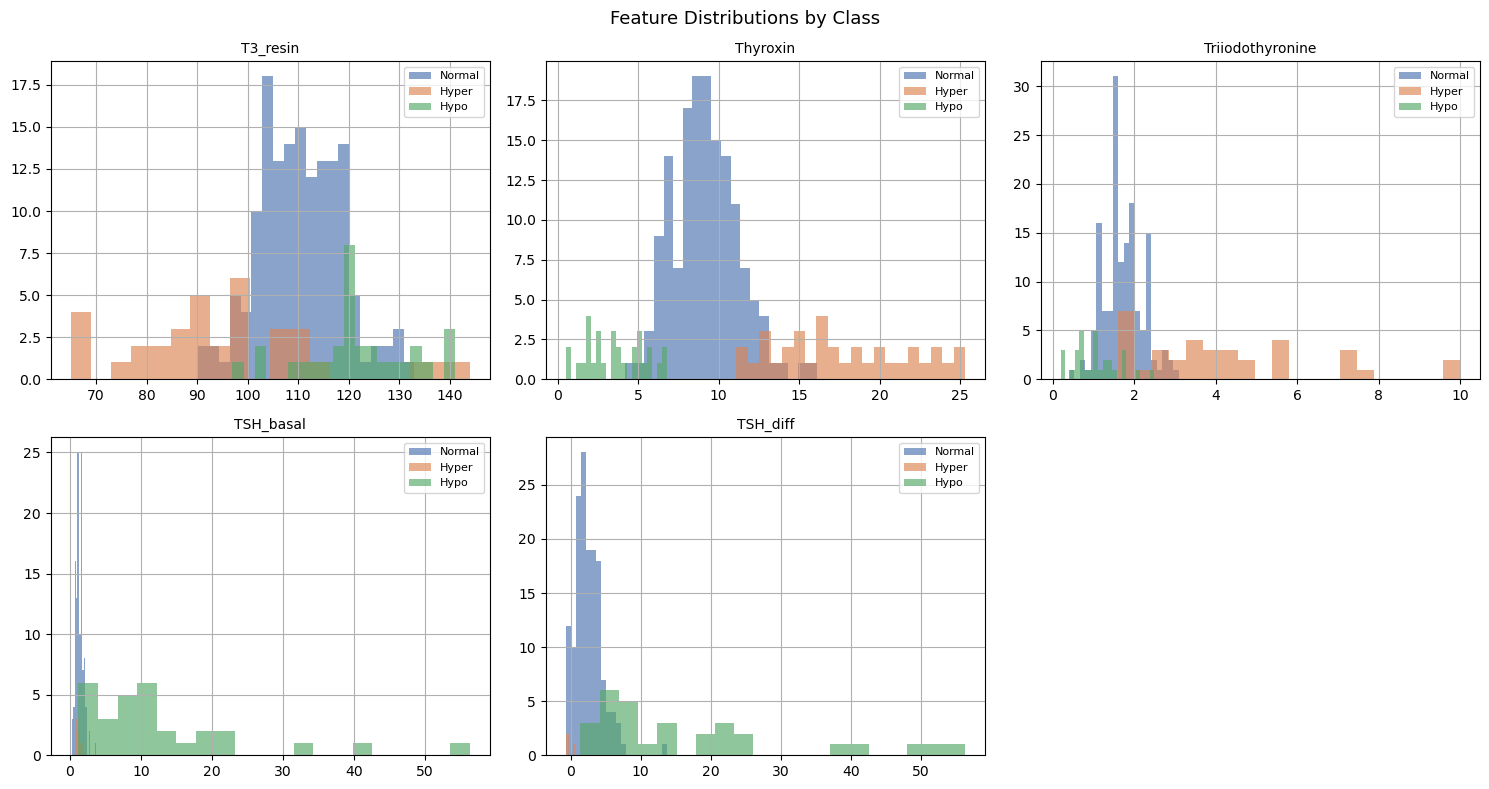

In [3]:
features = ['T3_resin','Thyroxin','Triiodothyronine','TSH_basal','TSH_diff']
colors   = {1:'#4C72B0', 2:'#DD8452', 3:'#55A868'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, feat in enumerate(features):
    ax = axes[i//3][i%3]
    for cls in [1,2,3]:
        df[df['class']==cls][feat].hist(ax=ax, alpha=0.65, bins=20,
                                        label=CLASS_NAMES[cls], color=colors[cls])
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=8)
fig.delaxes(axes[1][2])
plt.suptitle('Feature Distributions by Class', fontsize=13)
plt.tight_layout()
plt.savefig(str(EDA_DIR / 'feature_distributions.png'), dpi=150)
plt.show()


## 3. Boxplot — phát hiện outliers

C:\Users\HOME\AppData\Local\Temp\ipykernel_13316\1468809557.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=['Normal','Hyper','Hypo'], patch_artist=True,
C:\Users\HOME\AppData\Local\Temp\ipykernel_13316\1468809557.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=['Normal','Hyper','Hypo'], patch_artist=True,
C:\Users\HOME\AppData\Local\Temp\ipykernel_13316\1468809557.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=['Normal','Hyper','Hypo'], patch_artist=True,
C:\Users\HOME\AppData\Local\Temp\ipykernel_13316\1468809557.py:4

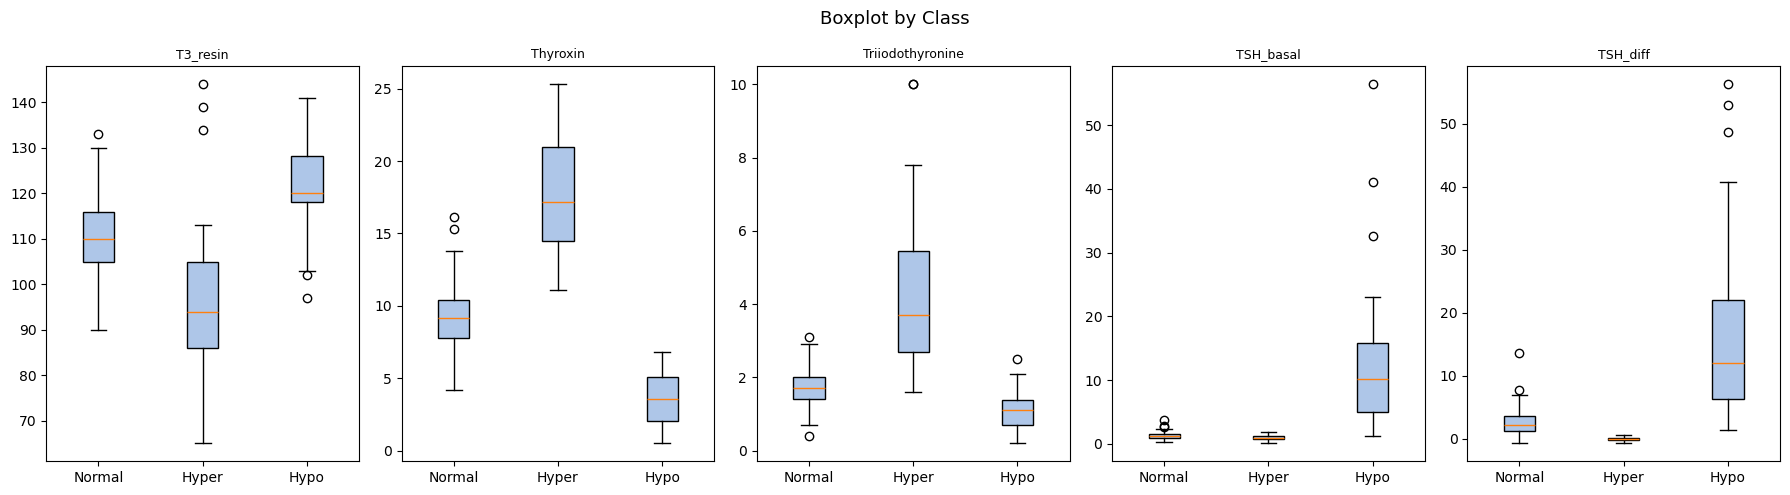

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, feat in enumerate(features):
    data = [df[df['class']==cls][feat].values for cls in [1,2,3]]
    axes[i].boxplot(data, labels=['Normal','Hyper','Hypo'], patch_artist=True,
                    boxprops=dict(facecolor='#AEC6E8'))
    axes[i].set_title(feat, fontsize=9)
plt.suptitle('Boxplot by Class', fontsize=13)
plt.tight_layout()
plt.savefig(str(EDA_DIR / 'boxplots.png'), dpi=150)
plt.show()


## 4. Correlation heatmap

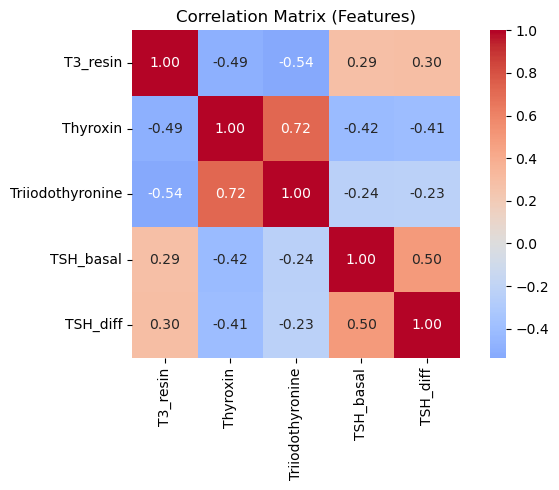

In [5]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix (Features)', fontsize=12)
plt.tight_layout()
plt.savefig(str(EDA_DIR / 'correlation_heatmap.png'), dpi=150)
plt.show()


## 5. Preprocessing & lưu processed data

In [6]:
# Tiền xử lý mức cơ bản:
# - Loại bỏ duplicate nếu có
# - Lưu phiên bản dữ liệu sạch vào data/processed
# - Không scale ở đây để tránh data leakage
# - Việc StandardScaler sẽ được thực hiện sau khi chia train/test ở notebook baseline và tuning

X, y, clean_df = preprocess(df, save_path='../data/processed/thyroid_processed.csv')

print('\nCleaned data shape:', clean_df.shape)
print('\nFeature preview:')
display(clean_df.head())
print('\nGhi chú: thyroid_processed.csv hiện là dữ liệu sạch, CHƯA scale.')


Saved cleaned data → ../data/processed/thyroid_processed.csv

Cleaned data shape: (215, 6)

Feature preview:


,T3_resin,Thyroxin,Triiodothyronine,TSH_basal,TSH_diff,class
0,107,10.1,2.2,0.9,2.7,1
1,113,9.9,3.1,2.0,5.9,1
2,127,12.9,2.4,1.4,0.6,1
3,109,5.3,1.6,1.4,1.5,1
4,105,7.3,1.5,1.5,-0.1,1



Ghi chú: thyroid_processed.csv hiện là dữ liệu sạch, CHƯA scale.
